In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce_master.csv", header=None)
df.columns = [
    "order_id",
    "customer_unique_id",
    "order_date",
    "total_price",
    "total_freight",
    "total_payment",
    "order_status",
    "order_month"
]
df.head()

,order_id,customer_unique_id,order_date,total_price,total_freight,total_payment,order_status,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,29.990000,8.720000,38.710001,delivered,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,118.699997,22.760000,141.460007,delivered,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,159.899994,19.219999,179.119995,delivered,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18,45.000000,27.200001,72.199997,delivered,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,19.900000,8.720000,28.620001,delivered,2018-02-01


In [3]:
print(df.columns)

Index(['order_id', 'customer_unique_id', 'order_date', 'total_price',
       'total_freight', 'total_payment', 'order_status', 'order_month'],
      dtype='str')


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M').dt.to_timestamp()

df.head()

,order_id,customer_unique_id,order_date,total_price,total_freight,total_payment,order_status,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,29.990000,8.720000,38.710001,delivered,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,118.699997,22.760000,141.460007,delivered,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,159.899994,19.219999,179.119995,delivered,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18,45.000000,27.200001,72.199997,delivered,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,19.900000,8.720000,28.620001,delivered,2018-02-01


Revenue trend

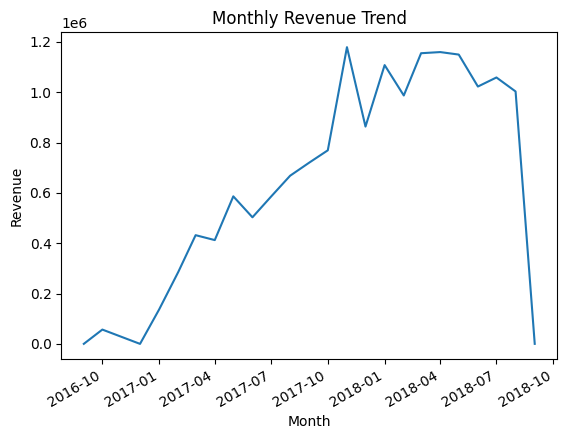

In [5]:
import matplotlib.pyplot as plt
revenue = df.groupby('order_month')['total_payment'].sum()

plt.figure()
revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [6]:
df['cohort_month'] = df.groupby('customer_unique_id')['order_month'].transform('min')
df['month_number'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 +
    (df['order_month'].dt.month - df['cohort_month'].dt.month)
)
cohort_data = df.groupby(['cohort_month', 'month_number'])['customer_unique_id'] \
                .nunique().reset_index()

pivot table

In [7]:
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='month_number',
    values='customer_unique_id'
)

retention rate

In [8]:
cohort_size = cohort_pivot[0]

retention = cohort_pivot.divide(cohort_size, axis=0)

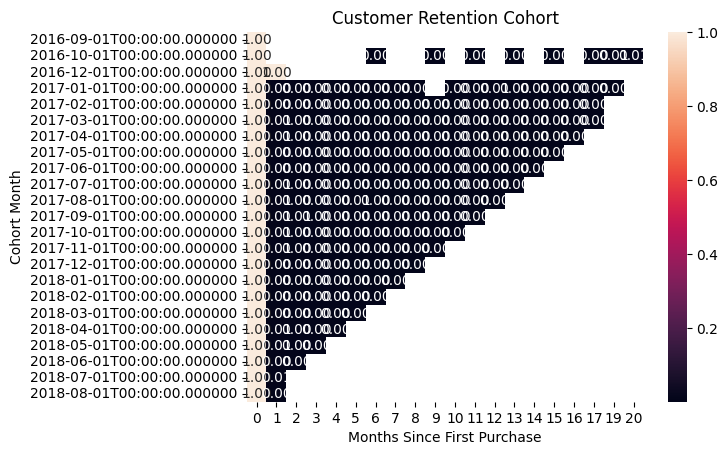

In [9]:
import seaborn as sns

plt.figure()
sns.heatmap(retention, annot=True, fmt=".2f")
plt.title("Customer Retention Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

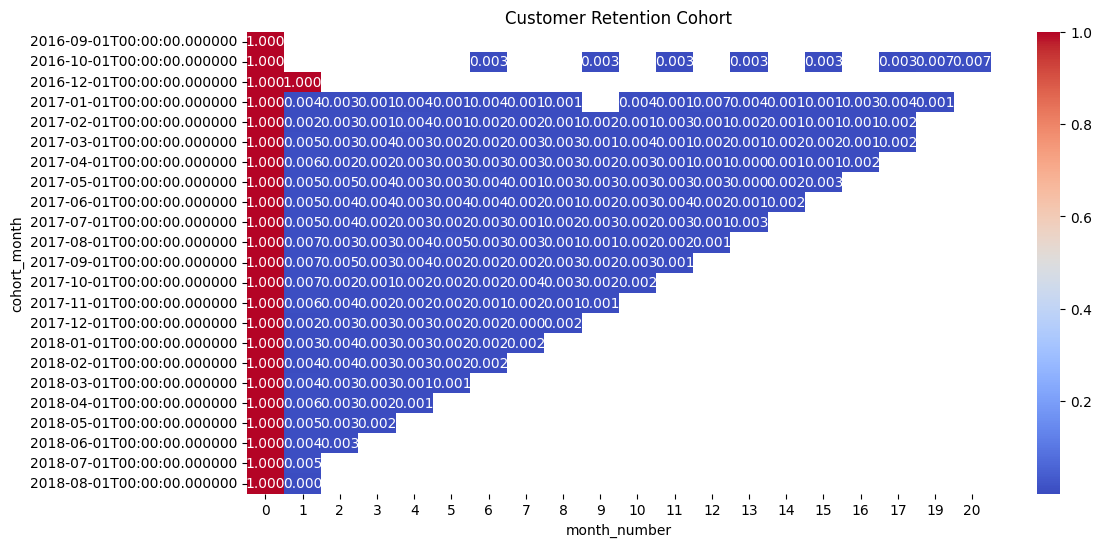

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".3f",   # 🔥 more precision
    cmap="coolwarm"
)

plt.title("Customer Retention Cohort")
plt.show()

Repeat vs new Customer

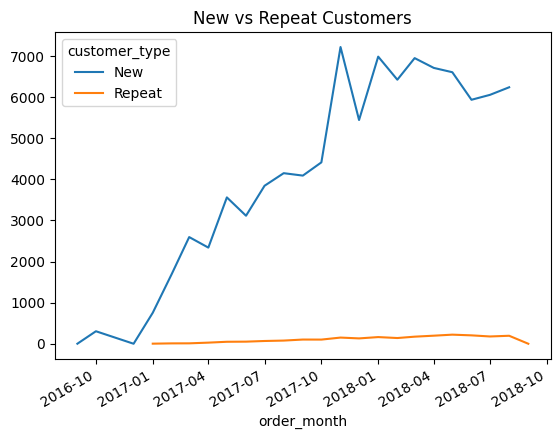

In [11]:
first_purchase = df.groupby('customer_unique_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'first_date']

df = df.merge(first_purchase, on='customer_unique_id')

df['customer_type'] = df.apply(
    lambda x: 'New' if x['order_date'] == x['first_date'] else 'Repeat',
    axis=1
)

customer_trend = df.groupby(['order_month', 'customer_type'])['customer_unique_id'] \
                   .nunique().unstack()

customer_trend.plot()
plt.title("New vs Repeat Customers")
plt.show()

AOV TREND

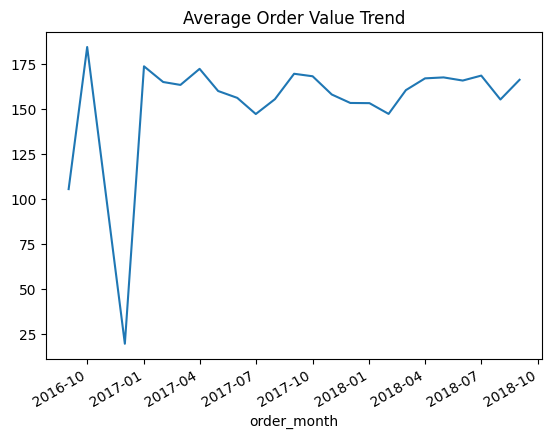

In [12]:
aov = df.groupby('order_month')['total_payment'].mean()

plt.figure()
aov.plot()
plt.title("Average Order Value Trend")
plt.show()

getting the csv file of the customer retention

In [13]:
cohort_long = retention.reset_index().melt(
    id_vars='cohort_month',
    var_name='month_number',
    value_name='retention_rate'
)

cohort_long.to_csv("cohort_retention_long.csv", index=False)